In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
data = {
    "Gender": [
        "Male","Male","Male","Male","Male",
        "Female","Female","Female","Female","Female",
        "Male","Female","Male","Female","Male",
        "Female","Male","Female","Male","Female"
    ],

    "Height": [
        170,175,180,165,172,
        160,158,162,168,155,
        178,164,182,159,176,
        167,185,161,174,163
    ],

    "Weight": [
        68,74,80,62,70,
        52,50,55,60,48,
        77,57,83,53,75,
        59,88,54,72,56
    ]
}

df = pd.DataFrame(data)

df.to_csv("body_weight_dataset.csv",index=False)

print("Dataset Created Successfully")

df.head()

Dataset Created Successfully


,Gender,Height,Weight
0,Male,170,68
1,Male,175,74
2,Male,180,80
3,Male,165,62
4,Male,172,70


In [ ]:
df = pd.read_csv("body_weight_dataset.csv")

df.head()

,Gender,Height,Weight
0,Male,170,68
1,Male,175,74
2,Male,180,80
3,Male,165,62
4,Male,172,70


In [ ]:
df.tail()

,Gender,Height,Weight
15,Female,167,59
16,Male,185,88
17,Female,161,54
18,Male,174,72
19,Female,163,56


In [ ]:
print("Shape of Dataset:",df.shape)

Shape of Dataset: (20, 3)


In [ ]:
df.columns

Index(['Gender', 'Height', 'Weight'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Gender  20 non-null     object
 1   Height  20 non-null     int64 
 2   Weight  20 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 612.0+ bytes


In [ ]:
df.isnull().sum()

,0
Gender,0
Height,0
Weight,0


In [ ]:
df.describe()

,Height,Weight
count,20.000000,20.000000
mean,168.700000,64.650000
std,8.700272,12.023114
min,155.000000,48.000000
25%,161.750000,54.750000
50%,167.500000,61.000000
75%,175.250000,74.250000
max,185.000000,88.000000


In [ ]:
df["Gender"] = df["Gender"].map({
    "Male":1,
    "Female":0
})

df.head()

,Gender,Height,Weight
0,1,170,68
1,1,175,74
2,1,180,80
3,1,165,62
4,1,172,70


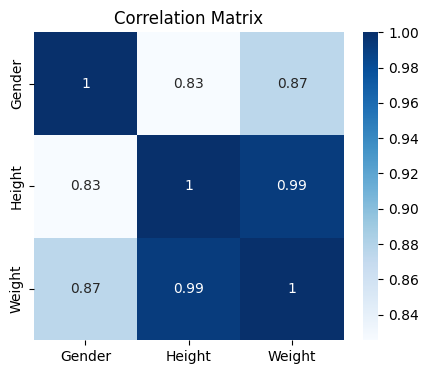

In [ ]:
plt.figure(figsize=(5,4))

sns.heatmap(df.corr(),annot=True,cmap="Blues")

plt.title("Correlation Matrix")

plt.show()

In [ ]:
X = df[["Gender","Height"]]

y = df["Weight"]

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred=model.predict(X_test)

In [ ]:
result=pd.DataFrame({
    "Actual Weight":y_test.values,
    "Predicted Weight":np.round(y_pred,2)
})

result

,Actual Weight,Predicted Weight
0,68,68.14
1,54,53.73
2,59,60.86
3,74,74.09


In [ ]:
mae=mean_absolute_error(y_test,y_pred)

print("Mean Absolute Error:",mae)

Mean Absolute Error: 0.5926751848280176


In [ ]:
mse=mean_squared_error(y_test,y_pred)

print("Mean Squared Error:",mse)

Mean Squared Error: 0.8946407654604904


In [ ]:
rmse=np.sqrt(mse)

print("Root Mean Squared Error:",rmse)

Root Mean Squared Error: 0.9458545160121035


In [ ]:
r2=r2_score(y_test,y_pred)

print("R² Score:",r2)

R² Score: 0.9851357712903761


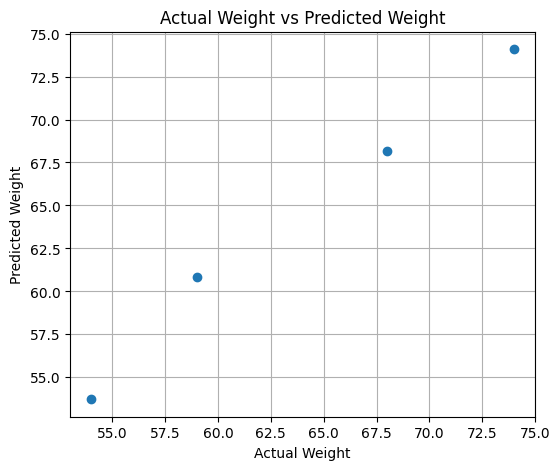

In [ ]:
plt.figure(figsize=(6,5))

plt.scatter(y_test,y_pred)

plt.xlabel("Actual Weight")

plt.ylabel("Predicted Weight")

plt.title("Actual Weight vs Predicted Weight")

plt.grid(True)

plt.show()

In [ ]:
new_person = pd.DataFrame({
    "Gender":[1],
    "Height":[178]
})

prediction=model.predict(new_person)

print("Predicted Weight =",round(prediction[0],2),"kg")

Predicted Weight = 77.66 kg
